In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/emotion-recognition-smartwatch-master (2).zip" -d "/content/emotion_recognition_HER"

In [3]:
# Change this path to where your ZIP is stored in Drive
zip_path = "/content/drive/MyDrive/emotion-recognition-using-speech-master.zip"

# Unzip into /content
!unzip -q "$zip_path" -d /content/

In [4]:
import os
import librosa
import numpy as np
import pandas as pd

DATA_PATH = "/content/emotion-recognition-using-speech-master/data/training"
FEATURES_CSV = "speech_features.csv"

features_list = []

for actor in os.listdir(DATA_PATH):
    actor_path = os.path.join(DATA_PATH, actor)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                file_path = os.path.join(actor_path, file)

                # Load audio
                y, sr = librosa.load(file_path, sr=None)

                # Extract MFCCs (mean of 40 coefficients)
                mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
                mfccs_mean = np.mean(mfccs.T, axis=0)

                # Extract label safely
                label = file.split("_")[-1].replace(".wav", "")

                # Append features + label
                features_list.append(np.append(mfccs_mean, label))

# Convert to DataFrame and save
df = pd.DataFrame(features_list)
df.to_csv(FEATURES_CSV, index=False)
print(f"Saved {len(features_list)} feature rows to {FEATURES_CSV}")

Saved 5202 feature rows to speech_features.csv


In [5]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, Multiply, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# ===============================
# Load Speech Features
# ===============================
speech_df = pd.read_csv("speech_features.csv")
X_speech = speech_df.iloc[:, :-1].values
y_speech = speech_df.iloc[:, -1].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_speech)

# ===============================
# Load HER (ECG) Features
# ===============================
her_path = "/content/emotion_recognition_HER/emotion-recognition-smartwatch-master/features"
her_files = [os.path.join(her_path, f) for f in os.listdir(her_path) if f.endswith(".csv")]

her_list = []
for f in her_files:
    df = pd.read_csv(f)
    her_list.append(df.values)

# Combine all HER data vertically
X_her = np.vstack(her_list)

# ===============================
# Match sample sizes
# ===============================
min_samples = min(X_speech.shape[0], X_her.shape[0])
X_speech = X_speech[:min_samples]
X_her = X_her[:min_samples]
y_encoded = y_encoded[:min_samples]

# ===============================
# Normalize features
# ===============================
scaler_speech = StandardScaler()
X_speech = scaler_speech.fit_transform(X_speech)

scaler_her = StandardScaler()
X_her = scaler_her.fit_transform(X_her)

# ===============================
# Train/Test Split
# ===============================
X_speech_train, X_speech_test, X_her_train, X_her_test, y_train, y_test = train_test_split(
    X_speech, X_her, y_encoded, test_size=0.2, random_state=42
)

# ===============================
# Build Fusion Model with Attention
# ===============================

# Speech branch
input_speech = Input(shape=(X_speech_train.shape[1],))
x1 = Dense(128, activation='relu')(input_speech)
x1 = Dropout(0.3)(x1)
x1 = Dense(64, activation='relu')(x1)

# HER branch
input_her = Input(shape=(X_her_train.shape[1],))
x2 = Dense(128, activation='relu')(input_her)
x2 = Dropout(0.3)(x2)
x2 = Dense(64, activation='relu')(x2)

# Attention Mechanism for Fusion
concat = Concatenate()([x1, x2])                 # Combine speech + HER
attention_probs = Dense(concat.shape[-1], activation='softmax')(concat)  # Learn weights
attention_mul = Multiply()([concat, attention_probs])  # Weighted fusion

# Classification layers
x = Dense(128, activation='relu')(attention_mul)
x = Dropout(0.4)(x)
output = Dense(len(np.unique(y_encoded)), activation='softmax')(x)

# Model
model = Model(inputs=[input_speech, input_her], outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

# ===============================
# Train Model
# ===============================
early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)

history = model.fit(
    [X_speech_train, X_her_train],
    y_train,
    validation_data=([X_speech_test, X_her_test], y_test),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop]
)

# ===============================
# Evaluate
# ===============================
loss, acc = model.evaluate([X_speech_test, X_her_test], y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 108)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      5,248 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     13,952 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128)       │          0 │ concatenate[0][0… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     16,512 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 8)         │      1,032 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,768 (272.53 KB)

 Trainable params: 69,768 (272.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.1909 - loss: 2.0367 - val_accuracy: 0.3775 - val_loss: 1.5851
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3867 - loss: 1.5855 - val_accuracy: 0.5293 - val_loss: 1.2361
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5305 - loss: 1.2106 - val_accuracy: 0.6302 - val_loss: 0.9999
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5903 - loss: 1.0439 - val_accuracy: 0.6657 - val_loss: 0.8642
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6408 - loss: 0.9622 - val_accuracy: 0.6609 - val_loss: 0.8319
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6473 - loss: 0.8959 - val_accuracy: 0.6926 - val_loss: 0.7939
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6727 - loss: 0.8281 - val_accuracy: 0.7070 - val_loss: 0.7595
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6707 - loss: 0.8417 - val_accuracy: 0.7147 -

131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Train Accuracy: 94.11%
Test Accuracy: 87.70%
Train F1-score: 94.16%
Test F1-score: 87.80%

Classification Report (Test Set):
              precision    recall  f1-score   support

       angry       0.95      0.90      0.92       187
        calm       0.67      0.73      0.70        59
     disgust       0.89      0.91      0.90       103
        fear       0.89      0.84      0.87       161
       happy       0.89      0.89      0.89       162
     neutral       0.94      0.90      0.92       112
          ps       0.80      0.89      0.84        97
         sad       0.84      0.88      0.86       160

    accuracy                           0.88      1041
   macro avg       0.86      0.87      0.86      1041
weighted avg       0.88      0.88      0.88      1041



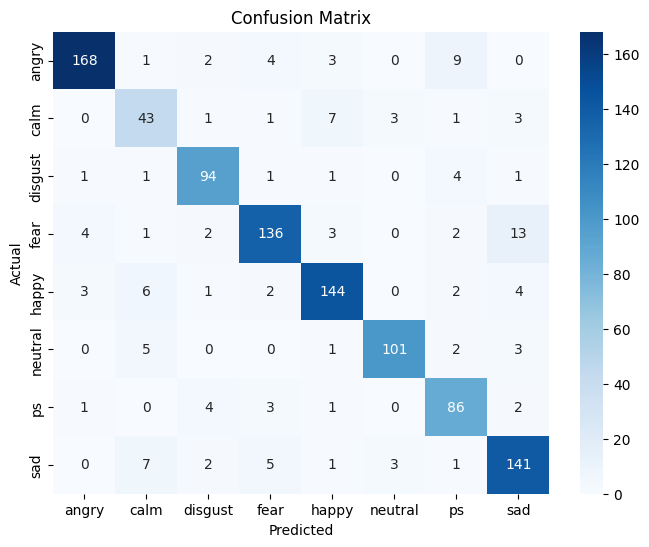

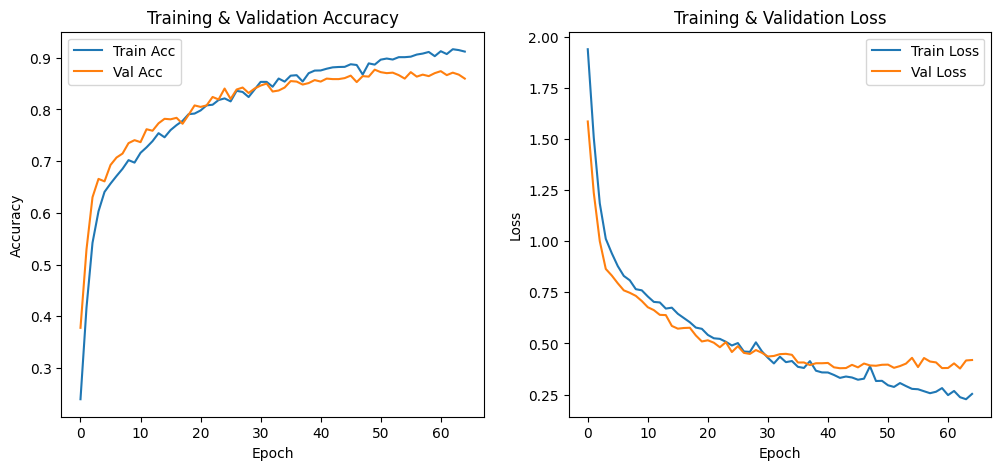

/tmp/ipython-input-391547355.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le.classes_, y=f1_per_class, palette="viridis")


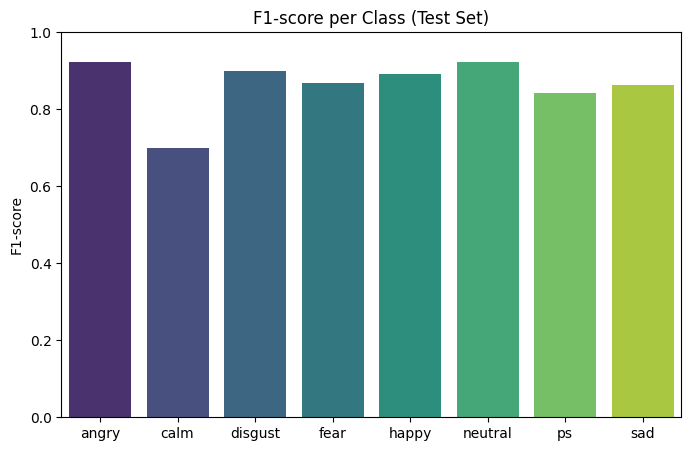

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import numpy as np

# ===============================
# Predict on train and test sets
# ===============================
y_train_pred_prob = model.predict([X_speech_train, X_her_train])
y_test_pred_prob = model.predict([X_speech_test, X_her_test])

# Convert probabilities to class labels
y_train_pred = np.argmax(y_train_pred_prob, axis=1)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

# ===============================
# Accuracy and F1-Score
# ===============================
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Train F1-score: {train_f1*100:.2f}%")
print(f"Test F1-score: {test_f1*100:.2f}%\n")

# ===============================
# Classification Report
# ===============================
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# ===============================
# Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ===============================
# Plot Training History
# ===============================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()

# ===============================
# Bar chart for F1-scores per class
# ===============================
report = classification_report(y_test, y_test_pred, target_names=le.classes_, output_dict=True)
f1_per_class = [report[cls]['f1-score'] for cls in le.classes_]

plt.figure(figsize=(8,5))
sns.barplot(x=le.classes_, y=f1_per_class, palette="viridis")
plt.ylabel('F1-score')
plt.title('F1-score per Class (Test Set)')
plt.ylim(0,1)
plt.show()


In [7]:
# Save entire model (architecture + weights + optimizer state)
model.save("/content/drive/MyDrive/Multimodal_Emotion_Models/Fusion_emotion_model.h5")
print("✅ Model saved to Google Drive as Fusion_emotion_model.h5")

✅ Model saved to Google Drive as Fusion_emotion_model.h5


In [8]:
from tensorflow.keras.models import load_model

# Load model from Drive
loaded_model = load_model("/content/drive/MyDrive/Multimodal_Emotion_Models/Fusion_emotion_model.h5")
print("✅ Model loaded from Google Drive")

✅ Model loaded from Google Drive
